<a href="https://colab.research.google.com/github/P202U/Voice-Emotion-Recognition/blob/main/Emotion_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import kagglehub
pathRAVDESS = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.


In [22]:
pathCREMA = kagglehub.dataset_download("ejlok1/cremad")

Using Colab cache for faster access to the 'cremad' dataset.


In [23]:
pathTESS = kagglehub.dataset_download("ejlok1/toronto-emotional-speech-set-tess")

Using Colab cache for faster access to the 'toronto-emotional-speech-set-tess' dataset.


In [24]:
pathSAVEE = kagglehub.dataset_download("ejlok1/surrey-audiovisual-expressed-emotion-savee")

Using Colab cache for faster access to the 'surrey-audiovisual-expressed-emotion-savee' dataset.


| Dataset | Filename Example | Logic to Extract Emotion | Example Label |
| :--- | :--- | :--- | :--- |
| **RAVDESS** | `03-01-05-01...wav` | 3rd numeric part | `05` (Angry) |
| **CREMA-D** | `1001_DFA_ANG_XX.wav` | 3rd string part | `ANG` (Angry) |
| **TESS** | `OAF_angry_back.wav` | 2nd string part | `angry` (Angry) |
| **SAVEE** | `DC_a01.wav` | Letter before the number | `a` (Angry) |

In [25]:
import os
import pandas as pd

def get_data(ravdess_p, crema_p, tess_p, savee_p):
    file_path = []
    emotion = []

    # 1. RAVDESS
    rav_map = {1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprised'}
    for dir in os.listdir(ravdess_p):
        if not dir.startswith('Actor'): continue
        for file in os.listdir(os.path.join(ravdess_p, dir)):
            part = file.split('.')[0].split('-')
            emotion.append(rav_map[int(part[2])])
            file_path.append(os.path.join(ravdess_p, dir, file))

    # 2. CREMA-D
    crema_map = {'SAD':'sad', 'ANG':'angry', 'DIS':'disgust', 'FEA':'fear', 'HAP':'happy', 'NEU':'neutral'}
    for file in os.listdir(crema_p):
        if file.endswith(".wav"):
            part = file.split('_')[2]
            if part in crema_map:
                emotion.append(crema_map[part])
                file_path.append(os.path.join(crema_p, file))

    # 3. TESS
    for dir in os.listdir(tess_p):
        label = dir.split('_')[-1].lower()
        if label == 'ps': label = 'surprised'

        target_dir = os.path.join(tess_p, dir)
        if os.path.isdir(target_dir):
            for file in os.listdir(target_dir):
                if file.endswith(".wav"):
                    emotion.append(label)
                    file_path.append(os.path.join(target_dir, file))

    # 4. SAVEE
    savee_map = {'a':'angry', 'd':'disgust', 'f':'fear', 'h':'happy', 'n':'neutral', 'sa':'sad', 'su':'surprised'}
    for file in os.listdir(savee_p):
        if file.endswith(".wav"):
            code = "".join([c for c in file.split('_')[1] if not c.isdigit()])
            if code in savee_map:
                emotion.append(savee_map[code])
                file_path.append(os.path.join(savee_p, file))

    return pd.DataFrame({'Path': file_path, 'Emotion': emotion})

In [26]:
df = get_data(pathRAVDESS, pathCREMA, pathTESS, pathSAVEE)

In [27]:
df

,Path,Emotion
0,/kaggle/input/ravdess-emotional-speech-audio/A...,surprised
1,/kaggle/input/ravdess-emotional-speech-audio/A...,neutral
2,/kaggle/input/ravdess-emotional-speech-audio/A...,disgust
3,/kaggle/input/ravdess-emotional-speech-audio/A...,disgust
4,/kaggle/input/ravdess-emotional-speech-audio/A...,neutral
...,...,...
1435,/kaggle/input/ravdess-emotional-speech-audio/A...,fear
1436,/kaggle/input/ravdess-emotional-speech-audio/A...,angry
1437,/kaggle/input/ravdess-emotional-speech-audio/A...,sad
1438,/kaggle/input/ravdess-emotional-speech-audio/A...,disgust


In [28]:
print(f"RAVDESS files: {len(os.listdir(pathRAVDESS))}")
print(f"CREMA files: {len(os.listdir(pathCREMA))}")
print(f"TESS folders: {len(os.listdir(pathTESS))}")
print(f"SAVEE files: {len(os.listdir(pathSAVEE))}")
print(len(df))

RAVDESS files: 25
CREMA files: 1
TESS folders: 2
SAVEE files: 1
1440


In [29]:
print("RAVDESS subfolders:", os.listdir(pathRAVDESS))
print("CREMA subfolders:", os.listdir(pathCREMA))
print("TESS subfolders:", os.listdir(pathTESS))
print("SAVEE subfolders:", os.listdir(pathSAVEE))

RAVDESS subfolders: ['Actor_02', 'Actor_17', 'Actor_05', 'Actor_16', 'Actor_21', 'Actor_01', 'Actor_11', 'Actor_20', 'Actor_08', 'Actor_15', 'Actor_06', 'Actor_12', 'Actor_23', 'Actor_24', 'Actor_22', 'Actor_04', 'Actor_19', 'Actor_10', 'Actor_09', 'audio_speech_actors_01-24', 'Actor_14', 'Actor_03', 'Actor_13', 'Actor_18', 'Actor_07']
CREMA subfolders: ['AudioWAV']
TESS subfolders: ['TESS Toronto emotional speech set data', 'tess toronto emotional speech set data']
SAVEE subfolders: ['ALL']


In [30]:
# RAVDESS
real_ravdess = pathRAVDESS

# CREMA
real_crema = os.path.join(pathCREMA, 'AudioWAV')

# TESS
real_tess = os.path.join(pathTESS, 'TESS Toronto emotional speech set data')

# SAVEE
real_savee = os.path.join(pathSAVEE, 'ALL')

df = get_data(real_ravdess, real_crema, real_tess, real_savee)

print(f"Success! Total files collected: {len(df)}")
print("\nDistribution of emotions:")
print(df['Emotion'].value_counts())

Success! Total files collected: 11682

Distribution of emotions:
Emotion
disgust      1863
angry        1863
fear         1863
sad          1863
happy        1863
neutral      1583
surprised     392
surprise      200
calm          192
Name: count, dtype: int64


In [31]:
df['Emotion'] = df['Emotion'].replace({'surprise': 'surprised'})

df['Emotion'] = df['Emotion'].replace({'calm': 'neutral'})

print(df['Emotion'].value_counts())

Emotion
disgust      1863
sad          1863
fear         1863
happy        1863
angry        1863
neutral      1775
surprised     592
Name: count, dtype: int64


In [32]:
import os
import librosa
import soundfile as sf
from tqdm import tqdm

output_dir = 'audio_16k'
if not os.path.exists(output_dir):
  os.makedirs(output_dir)

def convert_audio(df, target_sr=16000):
  new_paths = []

  print(f"Converting {len(df)} files to {target_sr}Hz, 16-bit...")

  for i, row in tqdm(df.iterrows(), total=len(df)):
    old_path = row['Path']
    file_name = f'{i}_{os.path.basename(old_path)}'
    new_path = os.path.join(output_dir, file_name)

    try:
      # load and resample to 16k Hz
      audio, sr = librosa.load(old_path, sr=target_sr)

      # Save as 16 bit PCM WAV
      sf.write(new_path, audio, target_sr, subtype='PCM_16')

      new_paths.append(new_path)
    except Exception as e:
      print(f"Error processing {old_path}: {e}")
      new_paths.append(None)

  return new_paths

In [33]:
df['Processed_Path'] = convert_audio(df)

df = df.dropna(subset=['Processed_Path'])

Converting 11682 files to 16000Hz, 16-bit...


100%|██████████| 11682/11682 [01:05<00:00, 177.31it/s]


In [34]:
df

,Path,Emotion,Processed_Path
0,/kaggle/input/ravdess-emotional-speech-audio/A...,surprised,audio_16k/0_03-01-08-01-01-01-02.wav
1,/kaggle/input/ravdess-emotional-speech-audio/A...,neutral,audio_16k/1_03-01-01-01-01-01-02.wav
2,/kaggle/input/ravdess-emotional-speech-audio/A...,disgust,audio_16k/2_03-01-07-02-01-02-02.wav
3,/kaggle/input/ravdess-emotional-speech-audio/A...,disgust,audio_16k/3_03-01-07-01-01-02-02.wav
4,/kaggle/input/ravdess-emotional-speech-audio/A...,neutral,audio_16k/4_03-01-01-01-02-01-02.wav
...,...,...,...
11677,/kaggle/input/toronto-emotional-speech-set-tes...,surprised,audio_16k/11677_YAF_witch_ps.wav
11678,/kaggle/input/toronto-emotional-speech-set-tes...,surprised,audio_16k/11678_YAF_shawl_ps.wav
11679,/kaggle/input/toronto-emotional-speech-set-tes...,surprised,audio_16k/11679_YAF_time_ps.wav
11680,/kaggle/input/toronto-emotional-speech-set-tes...,surprised,audio_16k/11680_YAF_road_ps.wav


# Data Augmentation

In [35]:
import numpy as np
import librosa

def add_noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    noise = noise_amp * np.random.normal(size=data.shape[0])
    return data + noise

def stretch(data, rate=0.7):
    return librosa.effects.time_stretch(y=data, rate=rate)

def shift(data):
    shift_range = int(np.random.randint(-5, 5) * 1000)
    return np.roll(data, shift_range)

def pitch(data, sr, pitch_factor=0.7):
    # n_steps is the parameter for librosa's pitch_shift
    # A factor of 0.7 is roughly -6 semitones
    return librosa.effects.pitch_shift(y=data, sr=sr, n_steps=pitch_factor)

# Feature Extration

In [36]:
def extract_features(data, sr):
    # Frame size = 2048, Hop length = 512
    n_fft = 2048
    hop_length = 512

    result = np.array([])

    # 1. ZCR: Mean of the transposed matrix
    zcr = librosa.feature.zero_crossing_rate(y=data, frame_length=n_fft, hop_length=hop_length)
    result = np.hstack((result, np.mean(zcr.T, axis=0)))

    # 2. Chroma: 12 distinct bins
    stft = np.abs(librosa.stft(data, n_fft=n_fft, hop_length=hop_length))
    chroma = librosa.feature.chroma_stft(S=stft, sr=sr)
    result = np.hstack((result, np.mean(chroma.T, axis=0)))

    # 3. MFCC: Spectral envelope
    mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)
    result = np.hstack((result, np.mean(mfcc.T, axis=0)))

    # 4. Root Mean Square (RMS): Average energy
    rms = librosa.feature.rms(y=data, frame_length=n_fft, hop_length=hop_length)
    result = np.hstack((result, np.mean(rms.T, axis=0)))

    # 5. Mel-Scaled Spectrogram
    mel = librosa.feature.melspectrogram(y=data, sr=sr, n_fft=n_fft, hop_length=hop_length)
    result = np.hstack((result, np.mean(mel.T, axis=0)))

    # 6. Spectral Rolloff (85% energy)
    rolloff = librosa.feature.spectral_rolloff(y=data, sr=sr, n_fft=n_fft, hop_length=hop_length, roll_percent=0.85)
    result = np.hstack((result, np.mean(rolloff.T, axis=0)))

    # 7. Spectral Contrast: Peak vs Valley
    contrast = librosa.feature.spectral_contrast(S=stft, sr=sr)
    result = np.hstack((result, np.mean(contrast.T, axis=0)))

    # 8. Tonnetz: Harmonic changes in tonal centroid
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(data), sr=sr)
    result = np.hstack((result, np.mean(tonnetz.T, axis=0)))

    return result

# The Merge

In [38]:
def get_all_features(path, sr=16000):
    data, sampling_rate = librosa.load(path, sr=sr)

    # 1. Original Data
    res1 = extract_features(data, sampling_rate)
    result = np.array(res1)

    # 2. Add Noise
    noise_data = add_noise(data)
    res2 = extract_features(noise_data, sampling_rate)
    result = np.vstack((result, res2))

    # 3. Stretch and Pitch
    str_data = stretch(data)
    pitch_data = pitch(str_data, sampling_rate)
    res3 = extract_features(pitch_data, sampling_rate)
    result = np.vstack((result, res3))

    return result

In [39]:
from joblib import Parallel, delayed
import numpy as np

# 1. Define the worker function
def process_single_file(path, emotion):
    try:
        features = get_all_features(path)
        return [(f, emotion) for f in features]
    except Exception as e:
        return []

# 2. Run in Parallel
# n_jobs=-1 tells computer to use all available CPU cores
print("Starting Parallel Feature Extraction...")
results = Parallel(n_jobs=-1)(
    delayed(process_single_file)(p, e) for p, e in tqdm(zip(df.Processed_Path, df.Emotion), total=len(df))
)

# 3. Flatten the nested list
# 'results' is a list of lists; this turns it into two simple arrays
X = []
Y = []
for sublist in results:
    for f, emotion in sublist:
        X.append(f)
        Y.append(emotion)

# 4. Convert to Numpy arrays for the Scaler
X = np.array(X)
Y = np.array(Y)

print(f"Final Data Shape: X = {X.shape}, Y = {Y.shape}")

Starting Parallel Feature Extraction...


100%|██████████| 11682/11682 [1:54:16<00:00,  1.70it/s]


Final Data Shape: X = (35046, 196), Y = (35046,)


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

X = np.array(X)
Y = np.array(Y)

# Encode labels ('angry' -> 0, 'happy' -> 1)
lb = LabelEncoder()
Y_encoded = lb.fit_transform(Y)


# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [41]:
# First split: 70% Train, 30% for (Val + Test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, Y_encoded, test_size=0.3, random_state=42, stratify=Y_encoded
)

# Second split: Split the 30% into two equal 15% parts
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# The Conv1D

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization

# Reshape for Conv1D: (batch, features, channels)
X_train_cnn = np.expand_dims(X_train, axis=2)
X_val_cnn = np.expand_dims(X_val, axis=2)
X_test_cnn = np.expand_dims(X_test, axis=2)

model = Sequential([
    # Layer 1
    Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=5, strides=2, padding='same'),
    Dropout(0.5),

    # Layer 2
    Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'),
    MaxPooling1D(pool_size=5, strides=2, padding='same'),
    Dropout(0.5),

    Flatten(),

    # Dense Layers
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(8, activation='softmax') # 8 emotions
])

# Optimizer and Early Stopping
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train for 100 epochs
history = model.fit(X_train_cnn, y_train, epochs=100, batch_size=32,
                    validation_data=(X_val_cnn, y_val), callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.3363 - loss: 1.6272 - val_accuracy: 0.4666 - val_loss: 1.3388
Epoch 2/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4181 - loss: 1.4291 - val_accuracy: 0.5039 - val_loss: 1.2375
Epoch 3/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4387 - loss: 1.3751 - val_accuracy: 0.5138 - val_loss: 1.2204
Epoch 4/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4450 - loss: 1.3514 - val_accuracy: 0.5208 - val_loss: 1.2026
Epoch 5/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4495 - loss: 1.3327 - val_accuracy: 0.5332 - val_loss: 1.2049
Epoch 6/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4634 - loss: 1.3145 - val_accuracy: 0.5319 - val_loss: 1.1765
Epoch 7/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4657 - loss: 1.3016 - val_accuracy: 0.5383 - val_loss: 1.1641
Epoch 8/100
767/767 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4714 - loss: 1.2938 - val_ac

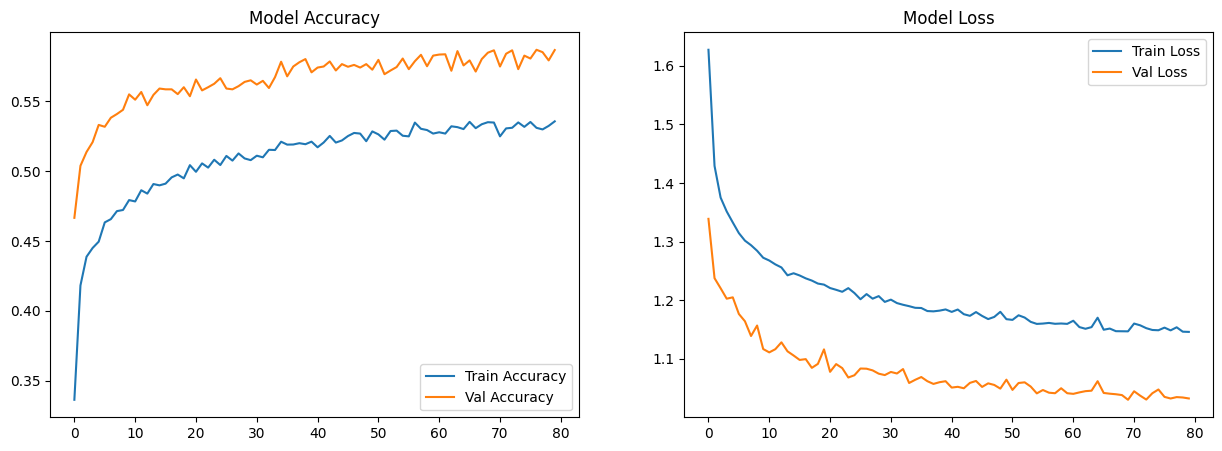

In [46]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    # Accuracy Plot
    axs[0].plot(history.history['accuracy'], label='Train Accuracy')
    axs[0].plot(history.history['val_accuracy'], label='Val Accuracy')
    axs[0].set_title('Model Accuracy')
    axs[0].legend()

    # Loss Plot
    axs[1].plot(history.history['loss'], label='Train Loss')
    axs[1].plot(history.history['val_loss'], label='Val Loss')
    axs[1].set_title('Model Loss')
    axs[1].legend()

    plt.show()

plot_history(history)

In [47]:
from sklearn.metrics import classification_report

# Predict with CNN
y_pred_cnn_probs = model.predict(X_test_cnn)
y_pred_cnn = np.argmax(y_pred_cnn_probs, axis=1)

print("--- CNN Classification Report ---")
print(classification_report(y_test, y_pred_cnn, target_names=lb.classes_))

165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
--- CNN Classification Report ---
              precision    recall  f1-score   support

       angry       0.80      0.67      0.73       839
     disgust       0.52      0.38      0.44       838
        fear       0.74      0.42      0.54       838
       happy       0.51      0.59      0.55       839
     neutral       0.45      0.74      0.56       798
         sad       0.57      0.63      0.60       839
   surprised       0.91      0.80      0.85       266

    accuracy                           0.58      5257
   macro avg       0.64      0.61      0.61      5257
weighted avg       0.61      0.58      0.58      5257



In [48]:
comparison_df = pd.DataFrame({
    'True_Label': y_test,
    'RF_Correct': y_pred == y_test,
    'CNN_Correct': y_pred_cnn == y_test
})

rf_only_correct = comparison_df[(comparison_df['RF_Correct'] == True) & (comparison_df['CNN_Correct'] == False)].shape[0]
cnn_only_correct = comparison_df[(comparison_df['RF_Correct'] == False) & (comparison_df['CNN_Correct'] == True)].shape[0]

print(f"RF found {rf_only_correct} samples the CNN missed.")
print(f"CNN found {cnn_only_correct} samples the RF missed.")

RF found 949 samples the CNN missed.
CNN found 332 samples the RF missed.


# Random Forest with RFE (Recursive Feature Elimination)

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE

rf_base = RandomForestClassifier(n_estimators=100, criterion='gini', max_depth=None, bootstrap=True, random_state=42)

print("Applying Recursive Feature Elimination...")
rfe = RFE(estimator=rf_base, n_features_to_select=93, step=5)
X_train_rfe = rfe.fit_transform(X_train, y_train)
X_test_rfe = rfe.transform(X_test)

rf_final = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)
rf_final.fit(X_train_rfe, y_train)

y_pred = rf_final.predict(X_test_rfe)
print(classification_report(y_test, y_pred, target_names=lb.classes_))

Applying Recursive Feature Elimination...
              precision    recall  f1-score   support

       angry       0.75      0.82      0.78       839
     disgust       0.65      0.60      0.62       838
        fear       0.81      0.55      0.66       838
       happy       0.67      0.67      0.67       839
     neutral       0.63      0.73      0.68       798
         sad       0.66      0.77      0.71       839
   surprised       0.92      0.89      0.90       266

    accuracy                           0.70      5257
   macro avg       0.73      0.72      0.72      5257
weighted avg       0.71      0.70      0.70      5257



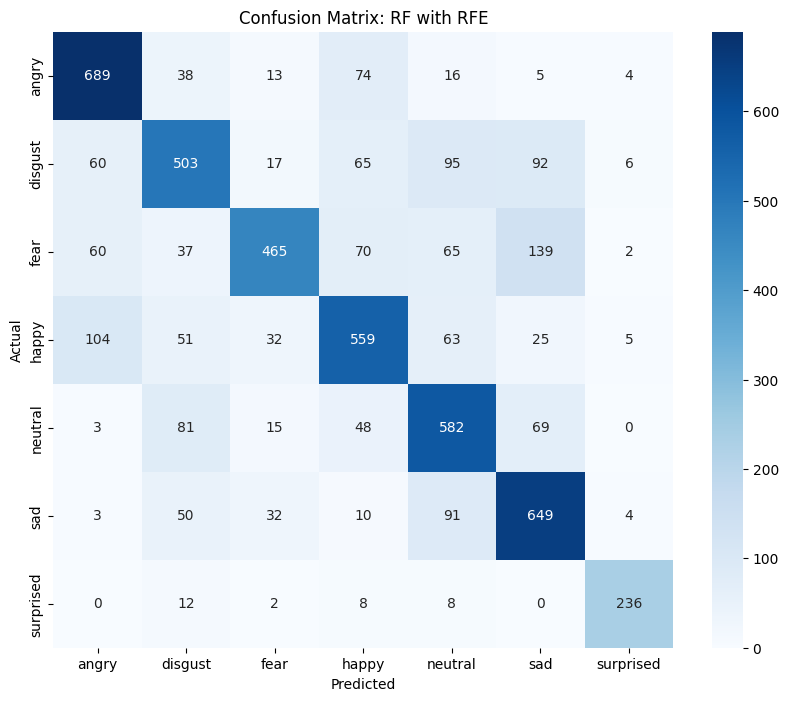

In [44]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=lb.classes_, yticklabels=lb.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: RF with RFE')
plt.show()

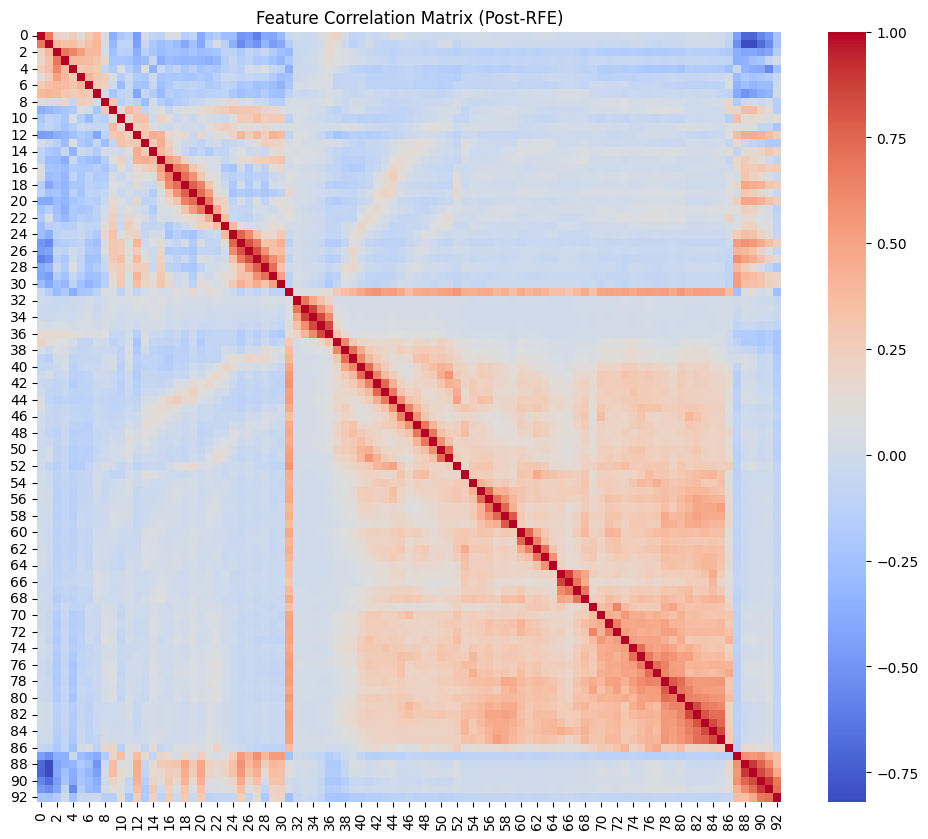

In [45]:
selected_features_df = pd.DataFrame(X_train_rfe)
corr_matrix = selected_features_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title('Feature Correlation Matrix (Post-RFE)')
plt.show()

In [50]:
print("CNN Classes (from LabelEncoder):", lb.classes_)
print("RF Classes (actually in model):", rf_final.classes_)

CNN Classes (from LabelEncoder): ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprised']
RF Classes (actually in model): [0 1 2 3 4 5 6]


In [51]:
cnn_probs_cleaned = cnn_probs[:, :7]

final_probs = (rf_probs * 0.7) + (cnn_probs_cleaned * 0.3)
ensemble_preds = np.argmax(final_probs, axis=1)

print("--- Ensemble Classification Report ---")
print(classification_report(y_test, ensemble_preds, target_names=lb.classes_))

--- Ensemble Classification Report ---
              precision    recall  f1-score   support

       angry       0.77      0.81      0.79       839
     disgust       0.65      0.58      0.61       838
        fear       0.84      0.56      0.67       838
       happy       0.65      0.66      0.66       839
     neutral       0.61      0.76      0.67       798
         sad       0.66      0.77      0.71       839
   surprised       0.91      0.88      0.90       266

    accuracy                           0.70      5257
   macro avg       0.73      0.71      0.71      5257
weighted avg       0.71      0.70      0.70      5257



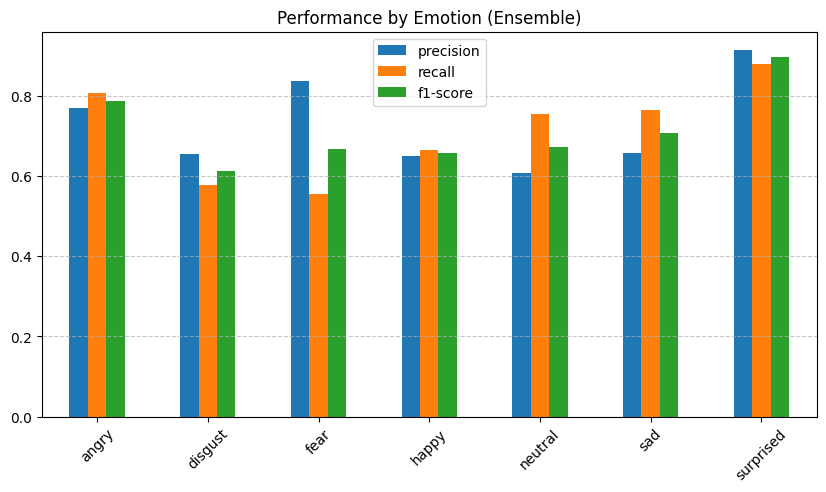

In [52]:
report = classification_report(y_test, ensemble_preds, target_names=lb.classes_, output_dict=True)
df_report = pd.DataFrame(report).iloc[:-1, :7].T

df_report[['precision', 'recall', 'f1-score']].plot(kind='bar', figsize=(10, 5))
plt.title('Performance by Emotion (Ensemble)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

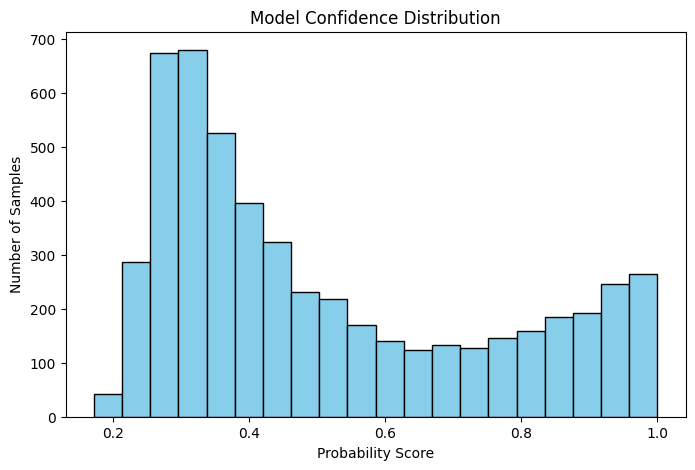

In [53]:
max_probs = np.max(final_probs, axis=1)

plt.figure(figsize=(8, 5))
plt.hist(max_probs, bins=20, color='skyblue', edgecolor='black')
plt.title('Model Confidence Distribution')
plt.xlabel('Probability Score')
plt.ylabel('Number of Samples')
plt.show()

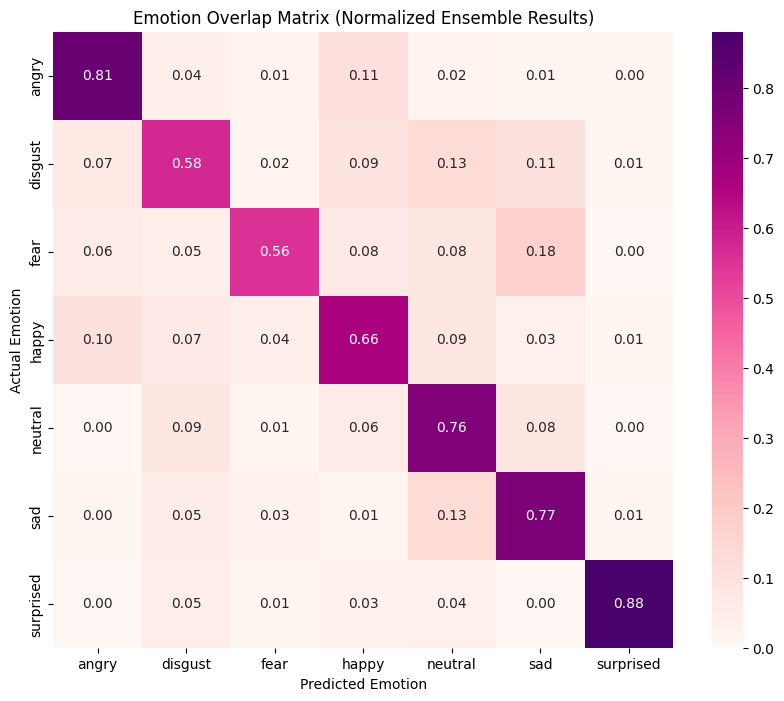

In [54]:
cm = confusion_matrix(y_test, ensemble_preds)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='RdPu',
            xticklabels=lb.classes_, yticklabels=lb.classes_)

plt.title('Emotion Overlap Matrix (Normalized Ensemble Results)')
plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.show()